# (teste) Timepoints bl / m12 / m24


In [2]:
from pathlib import Path

import pandas as pd

# --- config ---
INPUT_PATH = Path("csvs/adnimerged.csv")
OUTPUT_PATH = Path("csvs/adnimerged_longitudinal.csv")

BASELINE_VISITS = {"sc", "bl"}
FOLLOWUP_VISITS = ["m12", "m24"]#, "m36", "m48"]
CANONICAL_VISITS = BASELINE_VISITS | set(FOLLOWUP_VISITS)
MIN_IMAGES_PER_SET = 3
TARGET_GROUPS = ["CN", "sMCI", "pMCI", "AD"]


def visit_slot(visit: str) -> str:
    return "baseline" if visit in BASELINE_VISITS else visit


def assign_group(patient_df: pd.DataFrame):
    """GROUP definido só pelas visitas canônicas (sc/bl + m12 + m24)."""
    g = patient_df[patient_df["VISIT"].isin(CANONICAL_VISITS)].sort_values(
        ["MRI_DATE", "ID_IMG"]
    )
    if g.empty:
        return pd.NA

    diags = set(g["DIAG"])

    if diags == {"CN"}:
        return "CN"
    if diags == {"AD"}:
        return "AD"
    if diags == {"MCI"}:
        return "sMCI"
    if "MCI" in diags and "AD" in diags:
        return "pMCI"
    return pd.NA


def patient_has_all_required_visits(visit_set: set[str]) -> bool:
    return bool(visit_set & BASELINE_VISITS) and set(FOLLOWUP_VISITS).issubset(visit_set)


def one_image_per_slot(df: pd.DataFrame) -> pd.DataFrame:
    out = df[df["VISIT"].isin(CANONICAL_VISITS)].copy()
    out["slot"] = out["VISIT"].map(visit_slot)
    out = out.sort_values(["ID_PT", "slot", "MRI_DATE", "ID_IMG"])
    return out.drop_duplicates(["ID_PT", "slot"], keep="first")


def build_longitudinal_sets(
    df: pd.DataFrame,
    *,
    require_all_visits: bool,
    min_images: int = MIN_IMAGES_PER_SET,
) -> tuple[pd.DataFrame, pd.Series]:
    per_slot = one_image_per_slot(df)
    slots_per_pt = per_slot.groupby("ID_PT").size()
    visits_per_pt = df.groupby("ID_PT")["VISIT"].apply(set)

    eligible = slots_per_pt.index
    if require_all_visits:
        eligible = visits_per_pt[visits_per_pt.apply(patient_has_all_required_visits)].index
    else:
        has_baseline = per_slot.loc[per_slot["slot"] == "baseline", "ID_PT"].unique()
        eligible = pd.Index(has_baseline)

    eligible = eligible[slots_per_pt.reindex(eligible).fillna(0) >= min_images]
    longitudinal = per_slot[per_slot["ID_PT"].isin(eligible)].copy()
    longitudinal = longitudinal.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])
    return longitudinal, slots_per_pt.reindex(eligible)


# --- 1) leitura e remoção de repeats ---
raw = pd.read_csv(INPUT_PATH)
raw["MRI_DATE"] = pd.to_datetime(raw["MRI_DATE"], errors="coerce")

is_repeat = raw["DESCRIPTION"].str.contains("repeat", case=False, na=False)
df = raw.loc[~is_repeat].copy()

print(f"Linhas originais: {len(raw)} | removidas (repeat): {is_repeat.sum()} | restantes: {len(df)}")

# --- 2) GROUP por paciente (apenas visitas canônicas, sem repeat) ---
group_by_pt = df.groupby("ID_PT").apply(assign_group, include_groups=False)

print("\nPacientes por GROUP (visitas canônicas sc/bl + m12 + m24):")
print(group_by_pt.value_counts(dropna=False).sort_index())

# --- 3) coorte estrita: paciente com sc/bl + m12 + m24 + m36 + m48 ---
visits_by_pt = df.groupby("ID_PT")["VISIT"].apply(set)
strict_pts = visits_by_pt[visits_by_pt.apply(patient_has_all_required_visits)].index

longitudinal, _ = build_longitudinal_sets(
    df, require_all_visits=False, min_images=MIN_IMAGES_PER_SET
)
longitudinal["GROUP"] = longitudinal["ID_PT"].map(group_by_pt)
longitudinal = longitudinal[longitudinal["GROUP"].isin(TARGET_GROUPS)].copy()

df_flex = df[df["ID_PT"].isin(longitudinal["ID_PT"].unique())].copy()

# --- 5) salvar ---

longitudinal.to_csv(OUTPUT_PATH, index=False)
print(f"Salvo flexível: {OUTPUT_PATH} ({len(longitudinal)} linhas)")

display(longitudinal.groupby(["GROUP", "slot"]).size().unstack(fill_value=0))

Linhas originais: 12921 | removidas (repeat): 3757 | restantes: 9164

Pacientes por GROUP (visitas canônicas sc/bl + m12 + m24):
AD      165
CN      184
pMCI     99
sMCI    230
<NA>    625
Name: count, dtype: int64
Salvo flexível: csvs/adnimerged_longitudinal.csv (1221 linhas)


slot,baseline,m12,m24
GROUP,,,
AD,83,83,83
CN,136,136,136
pMCI,81,81,81
sMCI,107,107,107


In [3]:
ROW_ORDER = ["CN", "sMCI", "pMCI", "AD", "All"]
COL_ORDER = ["F", "M", "All"]

pacientes = longitudinal.drop_duplicates("ID_PT")

tabela_pacientes = (
    pd.crosstab(pacientes["GROUP"], pacientes["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

tabela_imagens = (
    pd.crosstab(longitudinal["GROUP"], longitudinal["SEX"], margins=True)
    .reindex(index=ROW_ORDER, columns=COL_ORDER)
    .astype(int)
)

# mantém tabela agregada (sem SEX) para o gráfico da célula seguinte
img_por_timepoint = (
    longitudinal.groupby(["GROUP", "slot"])["ID_IMG"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=["baseline", "m12", "m24"])
)

print("Pacientes (ID_PT) por GROUP × SEX:")
display(tabela_pacientes)

print("\nImagens (ID_IMG) por GROUP × SEX:")
display(tabela_imagens)

Pacientes (ID_PT) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,72,64,136
sMCI,38,69,107
pMCI,33,48,81
AD,41,42,83
All,184,223,407



Imagens (ID_IMG) por GROUP × SEX:


SEX,F,M,All
GROUP,,,
CN,216,192,408
sMCI,114,207,321
pMCI,99,144,243
AD,123,126,249
All,552,669,1221


In [4]:
DAYS_PER_MONTH = 30.4375
SLOT_ORDER = ["baseline", "m12", "m24"]


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


interval_cols = [
    "baseline→m12 (meses)",
    "m12→m24 (meses)",
    "baseline→m24 (meses)",
]

dates_by_pt = (
    longitudinal.pivot_table(
        index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
    )
    .reindex(columns=SLOT_ORDER)
)

dates_by_pt["bl_m12_m"] = (
    (dates_by_pt["m12"] - dates_by_pt["baseline"]).dt.days / DAYS_PER_MONTH
)
dates_by_pt["m12_m24_m"] = (
    (dates_by_pt["m24"] - dates_by_pt["m12"]).dt.days / DAYS_PER_MONTH
)
dates_by_pt["bl_m24_m"] = (
    (dates_by_pt["m24"] - dates_by_pt["baseline"]).dt.days / DAYS_PER_MONTH
)

interval_data = {}
for group in [*TARGET_GROUPS, "All"]:
    sub = dates_by_pt if group == "All" else dates_by_pt.xs(group, level="GROUP")
    interval_data[group] = {
        interval_cols[0]: mean_std(sub["bl_m12_m"]),
        interval_cols[1]: mean_std(sub["m12_m24_m"]),
        interval_cols[2]: mean_std(sub["bl_m24_m"]),
    }

tabela_intervalos = pd.DataFrame(interval_data).T.reindex([*TARGET_GROUPS, "All"])

print("Intervalo médio entre imagens (mean ± SD, em meses) — baseline / m12 / m24:")
display(tabela_intervalos)


Intervalo médio entre imagens (mean ± SD, em meses) — baseline / m12 / m24:


,baseline→m12 (meses),m12→m24 (meses),baseline→m24 (meses)
CN,12.96 ± 0.91,12.14 ± 1.06,25.10 ± 1.16
sMCI,12.88 ± 0.67,12.10 ± 0.84,24.98 ± 0.76
pMCI,12.77 ± 0.71,12.25 ± 1.13,25.03 ± 1.18
AD,12.86 ± 0.73,12.21 ± 1.49,25.07 ± 1.62
All,12.88 ± 0.78,12.17 ± 1.12,25.05 ± 1.19


In [5]:
# DAYS_PER_MONTH = 30.4375


# def mean_std(series: pd.Series) -> str:
#     m = series.mean()
#     s = series.std()
#     if pd.isna(m):
#         return ""
#     if pd.isna(s):
#         return f"{m:.2f} ± —"
#     return f"{m:.2f} ± {s:.2f}"


# interval_cols = ["t0→t1 (meses)", "t1→t2 (meses)", "t0→t2 (meses)"]

# dates_by_pt = (
#     longitudinal.pivot_table(
#         index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
#     )
#     .reindex(columns=SLOT_LABELS)
# )

# dates_by_pt["t0_t1_m"] = (dates_by_pt["t1"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH
# dates_by_pt["t1_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t1"]).dt.days / DAYS_PER_MONTH
# dates_by_pt["t0_t2_m"] = (dates_by_pt["t2"] - dates_by_pt["t0"]).dt.days / DAYS_PER_MONTH

# interval_data = {}
# for group in [*TARGET_GROUPS, "All"]:
#     sub = dates_by_pt if group == "All" else dates_by_pt.xs(group, level="GROUP")
#     interval_data[group] = {
#         interval_cols[0]: mean_std(sub["t0_t1_m"]),
#         interval_cols[1]: mean_std(sub["t1_t2_m"]),
#         interval_cols[2]: mean_std(sub["t0_t2_m"]),
#     }

# tabela_intervalos = pd.DataFrame(interval_data).T.reindex([*TARGET_GROUPS, "All"])

# print("Intervalo médio entre imagens (mean ± SD, em meses):")
# display(tabela_intervalos)


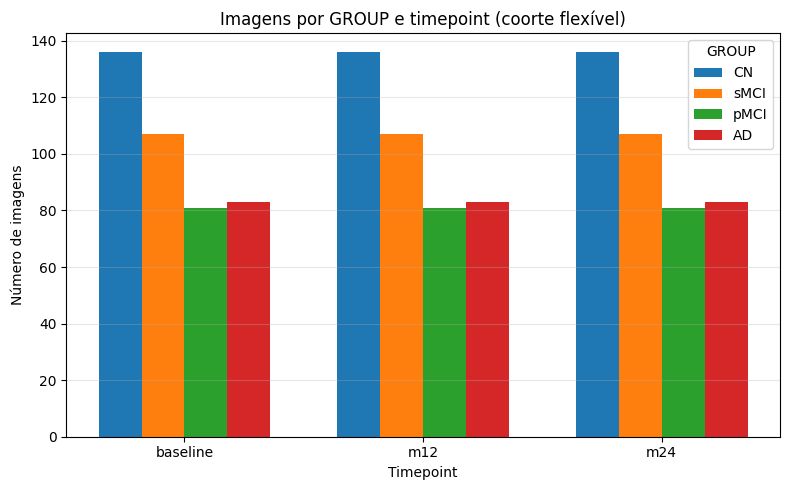

In [6]:
import matplotlib.pyplot as plt

plot_df = img_por_timepoint.reindex(TARGET_GROUPS)
x = plot_df.columns.tolist()
width = 0.18
groups = plot_df.index.tolist()
offsets = [(i - (len(groups) - 1) / 2) * width for i in range(len(groups))]

fig, ax = plt.subplots(figsize=(8, 5))
for offset, group in zip(offsets, groups):
    ax.bar(
        [i + offset for i in range(len(x))],
        plot_df.loc[group].values,
        width=width,
        label=group,
    )

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel("Timepoint")
ax.set_ylabel("Número de imagens")
ax.set_title("Imagens por GROUP e timepoint (coorte flexível)")
ax.legend(title="GROUP")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
CLINICAL_VARS = {
    "AGE": "Age (years)",
    "MMSE_SCORE": "MMSE",
    "ADAS_SCORE": "ADAS",
  # "CDR_GLOBAL": "CDR",
    "FAQ_SCORE": "FAQ",
}

SLOT_ORDER = ["baseline", "m12", "m24"]
SLOT_SUFFIX = {"baseline": "_bl", "m12": "_12m", "m24": "_24m"}


def mean_std(series: pd.Series) -> str:
    m = series.mean()
    s = series.std()
    if pd.isna(m):
        return ""
    if pd.isna(s):
        return f"{m:.2f} ± —"
    return f"{m:.2f} ± {s:.2f}"


def gender_m_f(series: pd.Series) -> str:
    return f"{(series == 'M').sum()}/{(series == 'F').sum()}"


row_labels = [
    f"{group}{SLOT_SUFFIX[slot]}"
    for group in TARGET_GROUPS
    for slot in SLOT_ORDER
]

col_order = [
    "Sample size",
    "Gender (male/female)",
    *CLINICAL_VARS.values(),
]

table_data = {}

for group in TARGET_GROUPS:
    for slot in SLOT_ORDER:
        row = f"{group}{SLOT_SUFFIX[slot]}"
        sub = longitudinal[
            (longitudinal["GROUP"] == group) & (longitudinal["slot"] == slot)
        ]

        table_data[row] = {
            "Sample size": len(sub),
            "Gender (male/female)": gender_m_f(sub["SEX"]),
        }
        for var, label in CLINICAL_VARS.items():
            table_data[row][label] = mean_std(sub[var])

tabela_caracteristicas = (
    pd.DataFrame(table_data)
    .T
    .reindex(index=row_labels)
    .reindex(columns=col_order)
)

print("Características por GROUP e timepoint (mean ± SD):")
display(tabela_caracteristicas)

print("\nNota: dados representados como média ± DP (SD).")



Características por GROUP e timepoint (mean ± SD):


,Sample size,Gender (male/female),Age (years),MMSE,ADAS,FAQ
CN_bl,136,64/72,76.18 ± 5.26,29.23 ± 0.97,5.64 ± 2.65,0.12 ± 0.46
CN_12m,136,64/72,77.29 ± 5.28,29.26 ± 1.10,5.39 ± 2.68,0.17 ± 0.93
CN_24m,136,64/72,78.26 ± 5.33,29.19 ± 1.02,5.37 ± 2.77,0.22 ± 0.83
sMCI_bl,107,69/38,75.04 ± 6.73,27.38 ± 1.76,10.13 ± 4.10,2.63 ± 3.75
sMCI_12m,107,69/38,76.09 ± 6.74,27.50 ± 2.08,10.13 ± 4.70,3.65 ± 4.42
sMCI_24m,107,69/38,77.11 ± 6.76,26.98 ± 2.67,11.58 ± 5.00,4.25 ± 4.89
pMCI_bl,81,48/33,74.63 ± 7.12,26.44 ± 1.64,13.17 ± 4.22,5.72 ± 4.81
pMCI_12m,81,48/33,75.67 ± 7.09,24.53 ± 2.85,15.46 ± 5.40,9.09 ± 5.52
pMCI_24m,81,48/33,76.70 ± 7.09,22.31 ± 3.88,18.72 ± 7.13,14.30 ± 6.13
AD_bl,83,42/41,75.93 ± 7.13,23.19 ± 1.92,18.78 ± 6.13,13.14 ± 6.78



Nota: dados representados como média ± DP (SD).


# Redefinição da população (do zero)

Objetivo: definir primeiro a trajetória clínica e, depois, selecionar **1 conjunto longitudinal por paciente** usando regra temporal comum.

## Variáveis

| Variável | Significado | Exemplos |
|----------|-------------|----------|
| `T_JANELA` | Horizonte clínico desde `t0` | 18, 24, 36, 48, 60 meses |
| `T_IMAGENS` | Gap mínimo entre imagens consecutivas | 3, 6, 9, 12 meses |
| `QTD_IMAGENS` | Nº fixo de imagens por conjunto | 3 (principal), 4, 5 |

## Definição clínica (antes da seleção de imagens)

- **pMCI:** `t0` = primeira MCI; todas as avaliações anteriores à primeira AD permanecem MCI; primeira AD ocorre em `(t0, t0 + T_JANELA]`; nenhum retorno posterior observado para MCI/CN.
- **sMCI:** `t0` = primeira MCI; todas as avaliações permanecem MCI até a primeira avaliação em/após `t0 + T_JANELA`; essa avaliação também deve ser MCI.
- **CN:** trajetória exclusivamente CN e confirmação CN em/após a janela.
- **AD:** trajetória exclusivamente AD desde a primeira AD.
- Sem confirmação pós-janela, desfecho intervalado ou trajetória mista/revertida → paciente excluído.

A designação sMCI significa **não conversor dentro da janela**, não estabilidade permanente.

## Seleção das imagens (depois do rótulo)

- `SOFT_PMCI=False`: somente imagens MCI entram nos preditores pMCI.
- `SOFT_PMCI=True`: quando faltam imagens MCI, a primeira AD pode completar exclusivamente o último slot. O diagnóstico observado permanece AD; `DIAG_EFFECTIVE=MCI_soft` registra a hipótese sem alterar o dado original.
- `T1` = primeira imagem elegível e `Tk` = última imagem elegível antes do limite clínico.
- Imagens intermediárias são as mais próximas dos pontos equidistantes entre `T1` e `Tk` (para 3 imagens, `T2` é o midpoint).
- Todos os gaps consecutivos devem ser ≥ `T_IMAGENS`.
- Mesma regra determinística para todos os grupos; slots representam ordem temporal, não visitas fixas m12/m24.
- Para soft, são reportados os intervalos entre slots e o tempo da última MCI observada até a primeira AD.

## Pipeline abaixo (somente tabelas)

1. Carregar ADNI sem repeats.
2. Resumir tempo MCI→AD para calibrar a janela.
3. Separar elegibilidade clínica de disponibilidade das imagens.
4. Mostrar contagens, exclusões, intervalos, tempo de conversão e grade comparativa.


## 1) Carregar ADNI (sem repeats)


In [1]:
from pathlib import Path

import pandas as pd

INPUT_PATH = Path("csvs/adnimerged.csv")
DAYS_PER_MONTH = 30.4375

raw = pd.read_csv(INPUT_PATH)
raw["MRI_DATE"] = pd.to_datetime(raw["MRI_DATE"], errors="coerce")
is_repeat = raw["DESCRIPTION"].str.contains("repeat", case=False, na=False)
df = raw.loc[~is_repeat].dropna(subset=["MRI_DATE", "DIAG", "ID_PT"]).copy()
df = df.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])

print(f"Linhas originais: {len(raw)}")
print(f"Removidas (repeat): {int(is_repeat.sum())}")
print(f"Restantes: {len(df)}")
print(f"Pacientes: {df['ID_PT'].nunique()}")
print(f"Diagnósticos: {sorted(df['DIAG'].dropna().unique().tolist())}")


Linhas originais: 12921
Removidas (repeat): 3757
Restantes: 9164
Pacientes: 1303
Diagnósticos: ['AD', 'CN', 'MCI']


## 2) Tempo de conversão MCI → AD

Âncora = **primeira MRI MCI**. Conversão = **primeira MRI AD** depois dessa âncora.  
Serve para calibrar `t_janela` (ex.: mediana ~19–20 meses → janela 36 meses cobre a maioria).


In [2]:
rows = []
for id_pt, g in df.groupby("ID_PT"):
    g = g.drop_duplicates("MRI_DATE", keep="first")
    if not {"MCI", "AD"}.issubset(set(g["DIAG"])):
        continue
    first_mci = g.loc[g["DIAG"] == "MCI", "MRI_DATE"].min()
    first_ad = g.loc[g["DIAG"] == "AD", "MRI_DATE"].min()
    if pd.isna(first_mci) or pd.isna(first_ad) or first_ad <= first_mci:
        continue
    mci_before = g[(g["DIAG"] == "MCI") & (g["MRI_DATE"] < first_ad)]
    last_mci = mci_before["MRI_DATE"].max()
    rows.append(
        {
            "ID_PT": id_pt,
            "meses_1a_MCI→AD": (first_ad - first_mci).days / DAYS_PER_MONTH,
            "meses_última_MCI→AD": (first_ad - last_mci).days / DAYS_PER_MONTH,
            "n_MCI_antes_AD": len(mci_before),
        }
    )

conv = pd.DataFrame(rows)
print(f"Conversores MCI→AD: {len(conv)} pacientes\n")


def _stats(s: pd.Series) -> dict:
    return {
        "n": int(s.notna().sum()),
        "média": round(s.mean(), 2),
        "mediana": round(s.median(), 2),
        "dp": round(s.std(), 2),
        "Q1": round(s.quantile(0.25), 2),
        "Q3": round(s.quantile(0.75), 2),
        "mín": round(s.min(), 2),
        "máx": round(s.max(), 2),
    }


resumo_conv = pd.DataFrame(
    {
        "1ª MCI → 1ª AD": _stats(conv["meses_1a_MCI→AD"]),
        "última MCI → 1ª AD": _stats(conv["meses_última_MCI→AD"]),
    }
).T
print("Resumo (meses):")
display(resumo_conv)

# CDF: quantos conversores cabem em cada janela
janelas = [12, 18, 24, 36, 48, 60, 72]
cdf = []
for w in janelas:
    n = int((conv["meses_1a_MCI→AD"] <= w).sum())
    cdf.append(
        {
            "t_janela (meses)": w,
            "conversores capturados": n,
            "% dos conversores": round(100 * n / len(conv), 1),
        }
    )
print("\nCDF — % conversores com 1ª MCI→AD ≤ t_janela:")
display(pd.DataFrame(cdf))

print("\nn MRI MCI antes da 1ª AD:")
display(
    conv["n_MCI_antes_AD"]
    .value_counts()
    .sort_index()
    .rename_axis("n_MCI")
    .reset_index(name="pacientes")
)


Conversores MCI→AD: 218 pacientes

Resumo (meses):


,n,média,mediana,dp,Q1,Q3,mín,máx
1ª MCI → 1ª AD,218.0,25.23,19.5,17.33,12.47,36.22,5.49,97.58
última MCI → 1ª AD,218.0,10.39,6.7,7.39,5.98,12.42,2.79,61.31



CDF — % conversores com 1ª MCI→AD ≤ t_janela:


,t_janela (meses),conversores capturados,% dos conversores
0,12,43,19.7
1,18,89,40.8
2,24,117,53.7
3,36,161,73.9
4,48,180,82.6
5,60,208,95.4
6,72,214,98.2



n MRI MCI antes da 1ª AD:


,n_MCI,pacientes
0,1,22
1,2,50
2,3,45
3,4,45
4,5,31
5,6,15
6,7,5
7,8,3
8,9,1
9,10,1


## 3) Definição clínica + seleção dos conjuntos

Altere `T_JANELA`, `T_IMAGENS` e `QTD_IMAGENS` e execute a célula.  
O rótulo clínico é definido antes da seleção das imagens; AD nunca entra nos preditores pMCI. A saída separa elegibilidade clínica, disponibilidade das imagens e motivos de exclusão.


In [3]:
from itertools import combinations

# === VARIÁVEIS (editar aqui) ===
T_JANELA = 36          # horizonte clínico desde t0
T_IMAGENS = 6          # gap mínimo entre imagens consecutivas
QTD_IMAGENS = 3        # 1 conjunto por paciente
SOFT_PMCI = True      # True: 1ª AD pode ser última imagem, mantendo diagnóstico observado

# Grade opcional (deixe [] para executar só a configuração acima)
GRADE_T_JANELA = [18, 24, 36, 48, 60]
GRADE_T_IMAGENS = [3, 6, 9, 12]
# ===============================

DIAG_SEV = {"CN": 0, "MCI": 1, "AD": 2}
TARGET_GROUPS = ["CN", "sMCI", "pMCI", "AD"]


def _dedup(g: pd.DataFrame) -> pd.DataFrame:
    return g.sort_values(["MRI_DATE", "ID_IMG"]).drop_duplicates("MRI_DATE", keep="first")


def _has_reversion(diags: list[str]) -> bool:
    sev = [DIAG_SEV[d] for d in diags if d in DIAG_SEV]
    return any(sev[i] > sev[i + 1] for i in range(len(sev) - 1))


def _pick_evenly_spaced(pool: pd.DataFrame, k: int, min_gap: float):
    """T1/Tk = extremos; intermediárias mais próximas dos pontos equidistantes."""
    pool = _dedup(pool)
    dates = pool["MRI_DATE"].tolist()
    n = len(dates)
    if n < k or k < 2:
        return None

    gap_days = min_gap * DAYS_PER_MONTH
    best = None
    for middle in combinations(range(1, n - 1), k - 2):
        idxs = (0, *middle, n - 1)
        if any((dates[b] - dates[a]).days < gap_days for a, b in zip(idxs, idxs[1:])):
            continue

        total_days = (dates[-1] - dates[0]).days
        targets = [dates[0] + pd.Timedelta(days=total_days * i / (k - 1)) for i in range(k)]
        error = sum(abs((dates[idx] - target).days) for idx, target in zip(idxs, targets))
        candidate = (error, idxs)
        if best is None or candidate < best:
            best = candidate

    return None if best is None else pool.iloc[list(best[1])].copy()


def classify_patient(g: pd.DataFrame, t_janela: float):
    """Define grupo clínico sem considerar disponibilidade das imagens preditoras."""
    g = _dedup(g)
    if g.empty:
        return None, "sem_dados"

    first_diag = g.iloc[0]["DIAG"]
    t0 = g.iloc[0]["MRI_DATE"]
    t_end = t0 + pd.DateOffset(months=int(t_janela))

    # Controles conservadores: trajetória inteira deve permanecer pura.
    if first_diag == "CN":
        if set(g["DIAG"]) != {"CN"}:
            return None, "trajetoria_mista"
        confirmation = g.loc[g["MRI_DATE"] >= t_end]
        if confirmation.empty:
            return None, "sem_confirmacao_pos_janela"
        return {
            "GROUP": "CN", "t0": t0, "t_end": t_end,
            "outcome_date": confirmation.iloc[0]["MRI_DATE"],
            "predictor_limit": t_end, "predictor_diag": "CN",
        }, "incluido"

    if first_diag == "AD":
        if set(g["DIAG"]) != {"AD"}:
            return None, "trajetoria_mista"
        return {
            "GROUP": "AD", "t0": t0, "t_end": t_end,
            "outcome_date": t0, "predictor_limit": t_end,
            "predictor_diag": "AD",
        }, "incluido"

    if first_diag != "MCI" or "CN" in set(g["DIAG"]):
        return None, "trajetoria_mista"

    # Qualquer retorno AD→MCI/CN observado exclui o paciente inteiro.
    if _has_reversion(g["DIAG"].tolist()):
        return None, "reversao_diagnostica"

    first_ad = g.loc[g["DIAG"] == "AD", "MRI_DATE"].min()
    if pd.notna(first_ad) and first_ad <= t_end:
        before_ad = g[(g["MRI_DATE"] >= t0) & (g["MRI_DATE"] < first_ad)]
        after_ad = g[g["MRI_DATE"] >= first_ad]
        if set(before_ad["DIAG"]) != {"MCI"} or set(after_ad["DIAG"]) != {"AD"}:
            return None, "trajetoria_mista"
        return {
            "GROUP": "pMCI", "t0": t0, "t_end": t_end,
            "outcome_date": first_ad, "predictor_limit": first_ad,
            "predictor_diag": "MCI",
        }, "incluido"

    # sMCI exige a primeira avaliação em/após o limite e diagnóstico ainda MCI.
    confirmation = g.loc[g["MRI_DATE"] >= t_end]
    if confirmation.empty:
        return None, "sem_confirmacao_pos_janela"
    confirmation = confirmation.iloc[0]
    if confirmation["DIAG"] != "MCI":
        return None, "desfecho_intervalado"
    through_confirmation = g[(g["MRI_DATE"] >= t0) & (g["MRI_DATE"] <= confirmation["MRI_DATE"])]
    if set(through_confirmation["DIAG"]) != {"MCI"}:
        return None, "trajetoria_mista"

    return {
        "GROUP": "sMCI", "t0": t0, "t_end": t_end,
        "outcome_date": confirmation["MRI_DATE"],
        "predictor_limit": t_end, "predictor_diag": "MCI",
    }, "incluido"


def select_images(
    g: pd.DataFrame,
    clinical: dict,
    t_imagens: float,
    qtd: int,
    soft_pmci: bool,
):
    """Seleciona extremos + intermediárias; soft permite somente a 1ª AD como última imagem."""
    g = _dedup(g)
    limit = clinical["predictor_limit"]
    if clinical["GROUP"] == "pMCI":
        before_limit = g["MRI_DATE"] < limit
    else:
        before_limit = g["MRI_DATE"] <= limit

    pool = g[
        (g["MRI_DATE"] >= clinical["t0"])
        & before_limit
        & (g["DIAG"] == clinical["predictor_diag"])
    ]
    selected = _pick_evenly_spaced(pool, qtd, t_imagens)
    used_soft = False

    if selected is None and soft_pmci and clinical["GROUP"] == "pMCI":
        first_ad = g[
            (g["MRI_DATE"] == clinical["outcome_date"])
            & (g["DIAG"] == "AD")
        ]
        if not first_ad.empty:
            soft_pool = pd.concat([pool, first_ad.iloc[[0]]], ignore_index=True)
            selected = _pick_evenly_spaced(soft_pool, qtd, t_imagens)
            used_soft = selected is not None

    if selected is None:
        return None

    # Preserva DIAG observado. DIAG_EFFECTIVE registra a hipótese soft sem alterar o dado bruto.
    selected["GROUP"] = clinical["GROUP"]
    selected["slot"] = [f"t{i}" for i in range(qtd)]
    selected["soft_pmci"] = used_soft
    selected["DIAG_EFFECTIVE"] = selected["DIAG"]
    if used_soft:
        if selected.iloc[-1]["DIAG"] != "AD" or (selected["DIAG"] == "AD").sum() != 1:
            raise ValueError("Soft pMCI deve conter exatamente 1 AD no último slot.")
        selected.loc[selected["DIAG"] == "AD", "DIAG_EFFECTIVE"] = "MCI_soft"

    selected["t0_anchor"] = clinical["t0"]
    selected["t_end"] = clinical["t_end"]
    selected["outcome_date"] = clinical["outcome_date"]

    if clinical["GROUP"] == "pMCI":
        mci_before_ad = g[
            (g["DIAG"] == "MCI")
            & (g["MRI_DATE"] >= clinical["t0"])
            & (g["MRI_DATE"] < clinical["outcome_date"])
        ]
        last_mci = mci_before_ad["MRI_DATE"].max()
        selected["last_mci_date"] = last_mci
        selected["last_mci_to_first_ad_months"] = (
            clinical["outcome_date"] - last_mci
        ).days / DAYS_PER_MONTH
    else:
        selected["last_mci_date"] = pd.NaT
        selected["last_mci_to_first_ad_months"] = float("nan")
    return selected


def classify_and_select(
    g: pd.DataFrame,
    t_janela: float,
    t_imagens: float,
    qtd: int,
    soft_pmci: bool,
):
    clinical, status = classify_patient(g, t_janela)
    if clinical is None:
        return None, None, status
    selected = select_images(g, clinical, t_imagens, qtd, soft_pmci)
    if selected is None:
        return clinical, None, "imagens_insuficientes"
    return clinical, selected, "incluido_soft" if selected["soft_pmci"].iloc[0] else "incluido"


def count_cohort(t_janela, t_imagens, qtd, soft_pmci=False, patients=None):
    clinical_counts = {group: 0 for group in TARGET_GROUPS}
    selected_counts = {group: 0 for group in TARGET_GROUPS}
    reasons = {}
    parts = []
    iterable = patients if patients is not None else df.groupby("ID_PT")

    for id_pt, g in iterable:
        clinical, selected, status = classify_and_select(
            g, t_janela, t_imagens, qtd, soft_pmci
        )
        reasons[status] = reasons.get(status, 0) + 1
        if clinical is None:
            continue
        clinical_counts[clinical["GROUP"]] += 1
        if selected is None:
            continue
        selected_counts[clinical["GROUP"]] += 1
        parts.append(selected)

    longitudinal = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    return clinical_counts, selected_counts, reasons, longitudinal


# cache por paciente (acelera a grade)
_patients = list(df.groupby("ID_PT"))

# --- configuração atual ---
clinical_counts, counts, exclusion_reasons, longitudinal = count_cohort(
    T_JANELA,
    T_IMAGENS,
    QTD_IMAGENS,
    soft_pmci=SOFT_PMCI,
    patients=_patients,
)

print("Configuração atual:")
display(
    pd.DataFrame(
        [
            {"parâmetro": "t_janela (meses)", "valor": T_JANELA},
            {"parâmetro": "t_imagens (meses)", "valor": T_IMAGENS},
            {"parâmetro": "qtd_imagens", "valor": QTD_IMAGENS},
            {"parâmetro": "SOFT_PMCI", "valor": SOFT_PMCI},
            {"parâmetro": "seleção", "valor": "extremos + pontos equidistantes"},
            {"parâmetro": "AD nos preditores", "valor": SOFT_PMCI},
        ]
    )
)

resumo = pd.DataFrame(
    [
        {
            "GROUP": group,
            "elegíveis clínicos": clinical_counts[group],
            "conjuntos com imagens": counts[group],
            "imagens": counts[group] * QTD_IMAGENS,
        }
        for group in TARGET_GROUPS
    ]
)
resumo.loc[len(resumo)] = {
    "GROUP": "All",
    "elegíveis clínicos": sum(clinical_counts.values()),
    "conjuntos com imagens": sum(counts.values()),
    "imagens": sum(counts.values()) * QTD_IMAGENS,
}
print("\nPopulação clínica e conjuntos finais (1 conjunto por paciente):")
display(resumo)
print(f"sMCI + pMCI finais = {counts['sMCI'] + counts['pMCI']}")
n_soft_current = (
    longitudinal.loc[longitudinal["soft_pmci"], "ID_PT"].nunique()
    if not longitudinal.empty else 0
)
print(f"pMCI soft = {n_soft_current}")

print("\nMotivos de exclusão / não seleção:")
display(
    pd.Series(exclusion_reasons, name="pacientes")
    .rename_axis("status")
    .sort_values(ascending=False)
    .reset_index()
)

# Intervalos médios entre slots.
if not longitudinal.empty and QTD_IMAGENS >= 2:
    slots = [f"t{i}" for i in range(QTD_IMAGENS)]
    wide = longitudinal.pivot_table(
        index=["ID_PT", "GROUP"], columns="slot", values="MRI_DATE", aggfunc="first"
    ).reindex(columns=slots)
    interval_rows = []
    groups_present = set(wide.index.get_level_values("GROUP"))
    for group in TARGET_GROUPS + ["All"]:
        if group != "All" and group not in groups_present:
            continue
        sub = wide if group == "All" else wide.xs(group, level="GROUP", drop_level=False)
        row = {"GROUP": group}
        for i in range(QTD_IMAGENS - 1):
            delta = (sub[slots[i + 1]] - sub[slots[i]]).dt.days / DAYS_PER_MONTH
            row[f"{slots[i]}→{slots[i + 1]}"] = f"{delta.mean():.2f} ± {delta.std():.2f}"
        span = (sub[slots[-1]] - sub[slots[0]]).dt.days / DAYS_PER_MONTH
        row[f"{slots[0]}→{slots[-1]}"] = f"{span.mean():.2f} ± {span.std():.2f}"
        interval_rows.append(row)
    print("\nIntervalos entre imagens (média ± dp, meses):")
    display(pd.DataFrame(interval_rows))

    pmci = longitudinal[longitudinal["GROUP"] == "pMCI"].drop_duplicates("ID_PT")
    if not pmci.empty:
        conversion = (pmci["outcome_date"] - pmci["t0_anchor"]).dt.days / DAYS_PER_MONTH
        print("\nTempo t0→AD nos pMCI finais (meses):")
        display(
            pd.DataFrame(
                {
                    "n": [len(conversion)],
                    "média": [round(conversion.mean(), 2)],
                    "dp": [round(conversion.std(), 2)],
                    "mediana": [round(conversion.median(), 2)],
                    "Q1": [round(conversion.quantile(0.25), 2)],
                    "Q3": [round(conversion.quantile(0.75), 2)],
                }
            )
        )

    soft_long = longitudinal[
        (longitudinal["GROUP"] == "pMCI") & longitudinal["soft_pmci"]
    ]
    if not soft_long.empty:
        soft_wide = soft_long.pivot_table(
            index="ID_PT", columns="slot", values="MRI_DATE", aggfunc="first"
        ).reindex(columns=slots)
        soft_row = {"pacientes soft": soft_long["ID_PT"].nunique()}
        for i in range(QTD_IMAGENS - 1):
            delta = (
                soft_wide[slots[i + 1]] - soft_wide[slots[i]]
            ).dt.days / DAYS_PER_MONTH
            soft_row[f"{slots[i]}→{slots[i + 1]} (média ± dp)"] = (
                f"{delta.mean():.2f} ± {delta.std():.2f}"
            )
        span = (soft_wide[slots[-1]] - soft_wide[slots[0]]).dt.days / DAYS_PER_MONTH
        soft_row[f"{slots[0]}→{slots[-1]} (média ± dp)"] = (
            f"{span.mean():.2f} ± {span.std():.2f}"
        )

        soft_patients = soft_long.drop_duplicates("ID_PT")
        last_mci_ad = soft_patients["last_mci_to_first_ad_months"]
        soft_row["última MCI observada→1ª AD (média ± dp)"] = (
            f"{last_mci_ad.mean():.2f} ± {last_mci_ad.std():.2f}"
        )
        soft_row["última MCI observada→1ª AD (mediana)"] = (
            f"{last_mci_ad.median():.2f}"
        )
        print("\nAuditoria dos conjuntos pMCI soft (meses):")
        display(pd.DataFrame([soft_row]))

# Grade comparativa: rótulo clínico + disponibilidade de imagens.
if GRADE_T_JANELA and GRADE_T_IMAGENS:
    grid_rows = []
    for tj in GRADE_T_JANELA:
        for ti in GRADE_T_IMAGENS:
            clinical, selected, _, grid_long = count_cohort(
                tj,
                ti,
                QTD_IMAGENS,
                soft_pmci=SOFT_PMCI,
                patients=_patients,
            )
            n_soft = (
                grid_long.loc[grid_long["soft_pmci"], "ID_PT"].nunique()
                if not grid_long.empty else 0
            )
            grid_rows.append(
                {
                    "t_janela": tj,
                    "t_imagens": ti,
                    "qtd": QTD_IMAGENS,
                    "soft": SOFT_PMCI,
                    "CN": selected["CN"],
                    "sMCI": selected["sMCI"],
                    "pMCI": selected["pMCI"],
                    "pMCI soft": n_soft,
                    "AD": selected["AD"],
                    "total": sum(selected.values()),
                    "sMCI+pMCI": selected["sMCI"] + selected["pMCI"],
                    "MCI clínicos": clinical["sMCI"] + clinical["pMCI"],
                }
            )
    grade = pd.DataFrame(grid_rows)
    print(f"\nGrade (qtd_imagens={QTD_IMAGENS}; SOFT_PMCI={SOFT_PMCI}):")
    display(grade)

    print("\nTop 5 por sMCI+pMCI:")
    display(grade.sort_values(["sMCI+pMCI", "total"], ascending=False).head(5))


Configuração atual:


,parâmetro,valor
0,t_janela (meses),36
1,t_imagens (meses),6
2,qtd_imagens,3
3,SOFT_PMCI,True
4,seleção,extremos + pontos equidistantes
5,AD nos preditores,True



População clínica e conjuntos finais (1 conjunto por paciente):


,GROUP,elegíveis clínicos,conjuntos com imagens,imagens
0,CN,168,156,468
1,sMCI,168,153,459
2,pMCI,154,90,270
3,AD,269,139,417
4,All,759,538,1614


sMCI + pMCI finais = 243
pMCI soft = 52

Motivos de exclusão / não seleção:


...

,pacientes soft,t0→t1 (média ± dp),t1→t2 (média ± dp),t0→t2 (média ± dp),última MCI observada→1ª AD (média ± dp),última MCI observada→1ª AD (mediana)
0,52,8.67 ± 2.78,9.34 ± 2.96,18.01 ± 4.97,7.93 ± 2.79,6.46



Grade (qtd_imagens=3; SOFT_PMCI=True):


,t_janela,t_imagens,qtd,soft,CN,sMCI,pMCI,pMCI soft,AD,total,sMCI+pMCI,MCI clínicos
0,18,3,3,True,209,276,58,52,171,714,334,410
1,18,6,3,True,101,126,25,25,81,333,151,410
2,18,9,3,True,0,0,0,0,0,0,0,410
3,18,12,3,True,0,0,0,0,0,0,0,410
4,24,3,3,True,207,260,86,54,174,727,346,399
5,24,6,3,True,108,177,52,41,88,425,229,399
6,24,9,3,True,10,16,4,4,10,40,20,399
7,24,12,3,True,0,0,0,0,0,0,0,399
8,36,3,3,True,160,161,124,54,182,627,285,322
9,36,6,3,True,156,153,90,52,139,538,243,322



Top 5 por sMCI+pMCI:


,t_janela,t_imagens,qtd,soft,CN,sMCI,pMCI,pMCI soft,AD,total,sMCI+pMCI,MCI clínicos
4,24,3,3,True,207,260,86,54,174,727,346,399
0,18,3,3,True,209,276,58,52,171,714,334,410
8,36,3,3,True,160,161,124,54,182,627,285,322
9,36,6,3,True,156,153,90,52,139,538,243,322
12,48,3,3,True,119,97,143,55,182,541,240,273


In [15]:
# 4) Características clínicas — DEFINA MANUALMENTE A CONFIGURAÇÃO AQUI
T_JANELA_OPTIMO = 36    # meses do horizonte clínico
T_IMAGENS_OPTIMO = 6    # gap mínimo entre imagens (meses)
QTD_IMAGENS_OPTIMO = 3  # imagens por conjunto
SOFT_PMCI_OPTIMO = True  # True: permite a 1ª AD como última imagem pMCI

# Recalcula a população exclusivamente com os valores acima.
clinical_counts_optimo, counts_optimo, exclusions_optimo, longitudinal_optimo = count_cohort(
    T_JANELA_OPTIMO,
    T_IMAGENS_OPTIMO,
    QTD_IMAGENS_OPTIMO,
    soft_pmci=SOFT_PMCI_OPTIMO,
    patients=_patients,
)

CLINICAL_VARS_OPTIMO = {
    "AGE": "Idade (anos)",
    "MMSE_SCORE": "MMSE",
    "ADAS_SCORE": "ADAS",
    "CDR_GLOBAL": "CDR global",
    "CDR_SB": "CDR-SB",
    "FAQ_SCORE": "FAQ",
}

if longitudinal_optimo.empty:
    raise ValueError("População vazia. Ajuste as três variáveis no início desta célula.")

missing = [column for column in CLINICAL_VARS_OPTIMO if column not in longitudinal_optimo.columns]
if missing:
    raise ValueError(f"Colunas clínicas ausentes: {missing}")


def mean_std_n(series: pd.Series) -> str:
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return ""
    if len(values) == 1:
        return f"{values.iloc[0]:.2f} ± — (n=1)"
    return f"{values.mean():.2f} ± {values.std():.2f} (n={len(values)})"


slots_optimo = [f"t{i}" for i in range(QTD_IMAGENS_OPTIMO)]
rows = []
for group in TARGET_GROUPS:
    for slot in slots_optimo:
        sub = longitudinal_optimo[
            (longitudinal_optimo["GROUP"] == group)
            & (longitudinal_optimo["slot"] == slot)
        ]
        if sub.empty:
            continue
        row = {
            "GROUP": group,
            "slot": slot,
            "pacientes": sub["ID_PT"].nunique(),
            "sexo M/F": f"{(sub['SEX'] == 'M').sum()}/{(sub['SEX'] == 'F').sum()}",
        }
        for column, label in CLINICAL_VARS_OPTIMO.items():
            row[label] = mean_std_n(sub[column])
        rows.append(row)

clinical_summary_optimo = pd.DataFrame(rows)
print(
    f"Configuração manual: t_janela={T_JANELA_OPTIMO}m | "
    f"t_imagens={T_IMAGENS_OPTIMO}m | qtd_imagens={QTD_IMAGENS_OPTIMO} | "
    f"soft_pmci={SOFT_PMCI_OPTIMO}"
)
n_soft_optimo = longitudinal_optimo.loc[
    longitudinal_optimo["soft_pmci"], "ID_PT"
].nunique()
print(
    f"Conjuntos: {sum(counts_optimo.values())} | "
    f"Imagens: {len(longitudinal_optimo)} | "
    f"sMCI+pMCI: {counts_optimo['sMCI'] + counts_optimo['pMCI']} | "
    f"pMCI soft: {n_soft_optimo}"
)
print("Valores: média ± desvio-padrão; n = valores não ausentes.")
display(clinical_summary_optimo)

# --- sMCI × pMCI: testes no timepoint t0 (1 paciente = 1 linha) ---
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu

STATS_SLOT = "t0"  # âncora comum; altere para "t2" se quiser comparar o último preditor


def _fmt_p(p: float) -> str:
    if pd.isna(p):
        return ""
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.4f}"


def _sig_label(p: float) -> str:
    if pd.isna(p):
        return ""
    return "sim (p<0.05)" if p < 0.05 else "não (p≥0.05)"


baseline_mci = (
    longitudinal_optimo[
        (longitudinal_optimo["GROUP"].isin(["sMCI", "pMCI"]))
        & (longitudinal_optimo["slot"] == STATS_SLOT)
    ]
    .drop_duplicates("ID_PT")
    .copy()
)
smci = baseline_mci[baseline_mci["GROUP"] == "sMCI"]
pmci = baseline_mci[baseline_mci["GROUP"] == "pMCI"]

stats_rows = []

# Sexo: χ² (ou Fisher se célula esperada < 5)
sex_ct = pd.crosstab(baseline_mci["GROUP"], baseline_mci["SEX"]).reindex(
    index=["sMCI", "pMCI"], columns=["M", "F"], fill_value=0
)
if sex_ct.to_numpy().sum() > 0 and sex_ct.shape == (2, 2):
    expected = chi2_contingency(sex_ct)[3]
    if (expected < 5).any():
        odds, p_sex = fisher_exact(sex_ct.to_numpy())
        sex_test = "Fisher exact"
    else:
        _, p_sex, _, _ = chi2_contingency(sex_ct)
        sex_test = "χ²"
else:
    p_sex = float("nan")
    sex_test = "—"

stats_rows.append(
    {
        "variável": "Sexo (M/F)",
        "slot": STATS_SLOT,
        "sMCI": f"{(smci['SEX'] == 'M').sum()}/{(smci['SEX'] == 'F').sum()} (n={len(smci)})",
        "pMCI": f"{(pmci['SEX'] == 'M').sum()}/{(pmci['SEX'] == 'F').sum()} (n={len(pmci)})",
        "teste": sex_test,
        "p-valor": _fmt_p(p_sex),
        "diferença significativa": _sig_label(p_sex),
        "leitura": (
            "proporção M/F difere entre classes — considerar estratificação GROUP×SEX no CV"
            if pd.notna(p_sex) and p_sex < 0.05
            else "sem evidência de desbalanceamento de sexo entre sMCI e pMCI"
        ),
    }
)

# Contínuas: Mann–Whitney U (two-sided)
for column, label in CLINICAL_VARS_OPTIMO.items():
    a = pd.to_numeric(smci[column], errors="coerce").dropna()
    b = pd.to_numeric(pmci[column], errors="coerce").dropna()
    if len(a) == 0 or len(b) == 0:
        p_val = float("nan")
        test_name = "—"
    else:
        _, p_val = mannwhitneyu(a, b, alternative="two-sided")
        test_name = "Mann–Whitney U"
    stats_rows.append(
        {
            "variável": label,
            "slot": STATS_SLOT,
            "sMCI": mean_std_n(smci[column]),
            "pMCI": mean_std_n(pmci[column]),
            "teste": test_name,
            "p-valor": _fmt_p(p_val),
            "diferença significativa": _sig_label(p_val),
            "leitura": (
                "grupos diferem — esperado em scores cognitivos se pMCI mais avançado; "
                "não implica balancear features clínicas"
                if label != "Idade (anos)" and pd.notna(p_val) and p_val < 0.05
                else (
                    "idade difere entre classes — reportar; checar como covariável/estrato"
                    if label == "Idade (anos)" and pd.notna(p_val) and p_val < 0.05
                    else "sem evidência de diferença entre sMCI e pMCI"
                )
            ),
        }
    )

# N das classes (desbalanceamento de rótulo — informativo, sem p)
stats_rows.append(
    {
        "variável": "N pacientes (rótulo)",
        "slot": STATS_SLOT,
        "sMCI": str(len(smci)),
        "pMCI": str(len(pmci)),
        "teste": "razão sMCI:pMCI",
        "p-valor": (
            f"{len(smci) / len(pmci):.2f}:1" if len(pmci) else "—"
        ),
        "diferença significativa": "—",
        "leitura": (
            "desbalanceamento de classes — no treino preferir AUC/AP e/ou class_weight; "
            "não confundir com p demográfico"
        ),
    }
)

stats_smci_pmci = pd.DataFrame(stats_rows)
print(
    f"\nsMCI × pMCI — testes no slot {STATS_SLOT} "
    f"(H0: mesmas distribuições / mesmas proporções; α=0.05):"
)
print(
    "p≥0.05 → sem evidência de diferença; "
    "p<0.05 → diferença estatística (sexo/idade: possível confundimento; "
    "cognição: frequentemente esperada)."
)
display(stats_smci_pmci)

# Auditoria temporal específica dos conjuntos que usam AD como último slot.
soft_optimo = longitudinal_optimo[
    (longitudinal_optimo["GROUP"] == "pMCI")
    & longitudinal_optimo["soft_pmci"]
]
if not soft_optimo.empty:
    soft_slots = [f"t{i}" for i in range(QTD_IMAGENS_OPTIMO)]
    soft_dates = soft_optimo.pivot_table(
        index="ID_PT", columns="slot", values="MRI_DATE", aggfunc="first"
    ).reindex(columns=soft_slots)
    temporal = {"pacientes soft": soft_optimo["ID_PT"].nunique()}
    for i in range(QTD_IMAGENS_OPTIMO - 1):
        delta = (
            soft_dates[soft_slots[i + 1]] - soft_dates[soft_slots[i]]
        ).dt.days / DAYS_PER_MONTH
        temporal[f"{soft_slots[i]}→{soft_slots[i + 1]} (média ± dp)"] = (
            f"{delta.mean():.2f} ± {delta.std():.2f}"
        )
    span = (
        soft_dates[soft_slots[-1]] - soft_dates[soft_slots[0]]
    ).dt.days / DAYS_PER_MONTH
    temporal[f"{soft_slots[0]}→{soft_slots[-1]} (média ± dp)"] = (
        f"{span.mean():.2f} ± {span.std():.2f}"
    )
    last_mci_ad = soft_optimo.drop_duplicates("ID_PT")[
        "last_mci_to_first_ad_months"
    ]
    temporal["última MCI observada→1ª AD (média ± dp)"] = (
        f"{last_mci_ad.mean():.2f} ± {last_mci_ad.std():.2f}"
    )
    temporal["última MCI observada→1ª AD (mediana)"] = (
        f"{last_mci_ad.median():.2f}"
    )
    print("\nAuditoria temporal pMCI soft (meses):")
    display(pd.DataFrame([temporal]))


Configuração manual: t_janela=36m | t_imagens=6m | qtd_imagens=3 | soft_pmci=True
Conjuntos: 538 | Imagens: 1614 | sMCI+pMCI: 243 | pMCI soft: 52
Valores: média ± desvio-padrão; n = valores não ausentes.


,GROUP,slot,pacientes,sexo M/F,Idade (anos),MMSE,ADAS,CDR global,CDR-SB,FAQ
0,CN,t0,156,76/80,74.92 ± 5.85 (n=156),29.14 ± 1.09 (n=156),5.54 ± 2.65 (n=156),0.00 ± 0.00 (n=156),0.02 ± 0.10 (n=156),0.10 ± 0.37 (n=156)
1,CN,t1,156,76/80,76.01 ± 5.86 (n=156),29.07 ± 1.25 (n=156),5.31 ± 2.78 (n=156),0.03 ± 0.12 (n=156),0.07 ± 0.25 (n=156),0.19 ± 0.91 (n=156)
2,CN,t2,156,76/80,76.98 ± 5.93 (n=156),29.21 ± 1.02 (n=156),5.16 ± 2.62 (n=156),0.03 ± 0.11 (n=156),0.07 ± 0.28 (n=156),0.19 ± 0.75 (n=156)
3,sMCI,t0,153,99/54,72.75 ± 7.09 (n=153),27.88 ± 1.70 (n=153),9.13 ± 3.53 (n=153),0.50 ± 0.00 (n=153),1.22 ± 0.62 (n=153),1.86 ± 2.92 (n=153)
4,sMCI,t1,153,99/54,73.81 ± 7.12 (n=153),28.02 ± 1.78 (n=153),8.68 ± 4.06 (n=153),0.47 ± 0.15 (n=153),1.32 ± 0.92 (n=153),2.51 ± 3.40 (n=153)
5,sMCI,t2,153,99/54,74.84 ± 7.09 (n=153),27.87 ± 2.10 (n=153),9.08 ± 4.53 (n=153),0.46 ± 0.17 (n=153),1.48 ± 1.17 (n=153),2.63 ± 3.61 (n=153)
6,pMCI,t0,90,51/39,74.13 ± 7.48 (n=90),26.66 ± 1.74 (n=90),13.01 ± 3.83 (n=90),0.50 ± 0.00 (n=90),1.97 ± 1.05 (n=90),5.71 ± 4.59 (n=90)
7,pMCI,t1,90,51/39,74.79 ± 7.41 (n=90),25.49 ± 2.27 (n=90),14.94 ± 5.34 (n=90),0.51 ± 0.05 (n=90),2.42 ± 1.07 (n=90),6.91 ± 5.00 (n=90)
8,pMCI,t2,90,51/39,75.53 ± 7.40 (n=90),24.53 ± 2.73 (n=90),16.31 ± 5.67 (n=90),0.66 ± 0.23 (n=90),3.69 ± 1.39 (n=90),10.49 ± 5.82 (n=90)
9,AD,t0,139,75/64,75.43 ± 7.66 (n=139),23.16 ± 1.94 (n=139),19.00 ± 5.98 (n=139),0.77 ± 0.27 (n=139),4.37 ± 1.51 (n=139),12.72 ± 6.66 (n=139)



sMCI × pMCI — testes no slot t0 (H0: mesmas distribuições / mesmas proporções; α=0.05):
p≥0.05 → sem evidência de diferença; p<0.05 → diferença estatística (sexo/idade: possível confundimento; cognição: frequentemente esperada).


,variável,slot,sMCI,pMCI,teste,p-valor,diferença significativa,leitura
0,Sexo (M/F),t0,99/54 (n=153),51/39 (n=90),χ²,0.2677,não (p≥0.05),sem evidência de desbalanceamento de sexo entr...
1,Idade (anos),t0,72.75 ± 7.09 (n=153),74.13 ± 7.48 (n=90),Mann–Whitney U,0.1358,não (p≥0.05),sem evidência de diferença entre sMCI e pMCI
2,MMSE,t0,27.88 ± 1.70 (n=153),26.66 ± 1.74 (n=90),Mann–Whitney U,2.18e-07,sim (p<0.05),grupos diferem — esperado em scores cognitivos...
3,ADAS,t0,9.13 ± 3.53 (n=153),13.01 ± 3.83 (n=90),Mann–Whitney U,1.85e-12,sim (p<0.05),grupos diferem — esperado em scores cognitivos...
4,CDR global,t0,0.50 ± 0.00 (n=153),0.50 ± 0.00 (n=90),Mann–Whitney U,1.0000,não (p≥0.05),sem evidência de diferença entre sMCI e pMCI
5,CDR-SB,t0,1.22 ± 0.62 (n=153),1.97 ± 1.05 (n=90),Mann–Whitney U,1.01e-08,sim (p<0.05),grupos diferem — esperado em scores cognitivos...
6,FAQ,t0,1.86 ± 2.92 (n=153),5.71 ± 4.59 (n=90),Mann–Whitney U,1.20e-14,sim (p<0.05),grupos diferem — esperado em scores cognitivos...
7,N pacientes (rótulo),t0,153,90,razão sMCI:pMCI,1.70:1,—,desbalanceamento de classes — no treino prefer...



Auditoria temporal pMCI soft (meses):


,pacientes soft,t0→t1 (média ± dp),t1→t2 (média ± dp),t0→t2 (média ± dp),última MCI observada→1ª AD (média ± dp),última MCI observada→1ª AD (mediana)
0,52,8.67 ± 2.78,9.34 ± 2.96,18.01 ± 4.97,7.93 ± 2.79,6.46


In [16]:
# 5) Salvar exatamente a população escolhida manualmente na célula anterior
OUTPUT_OPTIMO = Path("csvs/adnimerged_longitudinal_optimo.csv")

if longitudinal_optimo.empty:
    raise ValueError("População vazia. Execute primeiro a célula de características clínicas.")

sizes = longitudinal_optimo.groupby("ID_PT").size()
if not sizes.eq(QTD_IMAGENS_OPTIMO).all():
    raise ValueError("Cada paciente deve possuir exatamente QTD_IMAGENS_OPTIMO linhas.")

if longitudinal_optimo.groupby("ID_PT")["GROUP"].nunique().gt(1).any():
    raise ValueError("Há paciente associado a mais de um grupo.")

pmci_ad = longitudinal_optimo[
    (longitudinal_optimo["GROUP"] == "pMCI")
    & (longitudinal_optimo["DIAG"] == "AD")
]
if not SOFT_PMCI_OPTIMO and not pmci_ad.empty:
    raise ValueError("Imagem AD encontrada com SOFT_PMCI_OPTIMO=False.")
if SOFT_PMCI_OPTIMO:
    non_soft_ad = longitudinal_optimo[
        (longitudinal_optimo["GROUP"] == "pMCI")
        & ~longitudinal_optimo["soft_pmci"]
        & (longitudinal_optimo["DIAG"] == "AD")
    ]
    if not non_soft_ad.empty:
        raise ValueError("AD encontrada em conjunto pMCI não-soft.")
    ad_per_soft = (
        longitudinal_optimo[longitudinal_optimo["soft_pmci"]]
        .groupby("ID_PT")["DIAG"]
        .apply(lambda values: int((values == "AD").sum()))
    )
    if not ad_per_soft.eq(1).all():
        raise ValueError("Cada conjunto soft deve conter exatamente uma AD.")

slot_order = {f"t{i}": i for i in range(QTD_IMAGENS_OPTIMO)}
longitudinal_optimo = longitudinal_optimo.copy()
longitudinal_optimo["PARAM_T_JANELA"] = T_JANELA_OPTIMO
longitudinal_optimo["PARAM_T_IMAGENS"] = T_IMAGENS_OPTIMO
longitudinal_optimo["PARAM_QTD_IMAGENS"] = QTD_IMAGENS_OPTIMO
longitudinal_optimo["PARAM_SOFT_PMCI"] = SOFT_PMCI_OPTIMO
longitudinal_optimo["PARAM_SELECTION"] = "extremos_e_pontos_equidistantes"
longitudinal_optimo["_slot_order"] = longitudinal_optimo["slot"].map(slot_order)
longitudinal_optimo = (
    longitudinal_optimo
    .sort_values(["GROUP", "ID_PT", "_slot_order", "MRI_DATE", "ID_IMG"])
    .drop(columns="_slot_order")
)

OUTPUT_OPTIMO.parent.mkdir(parents=True, exist_ok=True)
longitudinal_optimo.to_csv(OUTPUT_OPTIMO, index=False)

print(f"Salvo: {OUTPUT_OPTIMO}")
print(
    f"Configuração: {T_JANELA_OPTIMO}/{T_IMAGENS_OPTIMO}/{QTD_IMAGENS_OPTIMO} | "
    f"soft={SOFT_PMCI_OPTIMO} | "
    f"Pacientes/conjuntos: {longitudinal_optimo['ID_PT'].nunique()} | "
    f"Imagens: {len(longitudinal_optimo)}"
)
display(
    longitudinal_optimo.drop_duplicates("ID_PT")["GROUP"]
    .value_counts()
    .reindex(TARGET_GROUPS, fill_value=0)
    .rename("pacientes (= conjuntos)")
    .to_frame()
)


Salvo: csvs/adnimerged_longitudinal_optimo.csv
Configuração: 36/6/3 | soft=True | Pacientes/conjuntos: 538 | Imagens: 1614


,pacientes (= conjuntos)
GROUP,
CN,156
sMCI,153
pMCI,90
AD,139


# preparação para teste volumetrico

In [10]:
# 6) Export vol-only → vol_long.csv (sem rad/disp) para ablação na pop optimo
# Pré-req: python feat_vol.py (IMAGES_CSV=optimo, OUT em BASE abaixo).
# Depois: CLI impresso no final.

from pathlib import Path

import pandas as pd
from ablation_prep import ROI_FILTER_DEFAULT, assign_scanner_batch

OPTIMO_CSV = Path("csvs/adnimerged_longitudinal_optimo.csv")
BASE = Path("csvs/longitudinal_optimo_4_groups")
VOL_CSV = BASE / "features_volumetric.csv"
ROI = ROI_FILTER_DEFAULT  # hippocampus
OUT_VOL_LONG = BASE / "ablation" / ROI / "vol_long.csv"

VOL_FEAT_COLS = [
    "mask_mm3", "gm_mm3", "gm_norm", "wm_mm3", "wm_norm",
    "csf_mm3", "csf_norm", "tissues_mm3", "tissues_norm",
]
VOL_SIZE_COLS = ["mask_mm3", "gm_mm3", "wm_mm3", "csf_mm3", "tissues_mm3"]
META_COLS = [
    "ID_IMG", "ID_PT", "GROUP", "SEX", "AGE", "MRI_DATE", "DIAG", "slot",
    "FIELD_STRENGTH", "MANUFACTURER", "MFG_MODEL",
    "MMSE_SCORE", "CDR_GLOBAL", "ADAS_SCORE", "FAQ_SCORE",
]
ROWS_PER_PT = 6  # L+R × 3 slots

if not VOL_CSV.is_file():
    raise FileNotFoundError(
        f"Falta {VOL_CSV}. Em feat_vol.py: "
        f'IMAGES_CSV="{OPTIMO_CSV}", ab="{BASE.name}", depois python feat_vol.py'
    )

try:
    optimo = longitudinal_optimo.copy()
    if optimo.empty:
        raise ValueError("longitudinal_optimo vazio")
except (NameError, ValueError):
    optimo = pd.read_csv(OPTIMO_CSV)

optimo["ID_IMG"] = optimo["ID_IMG"].astype(str).str.strip()
meta = (
    optimo[[c for c in META_COLS if c in optimo.columns]]
    .drop_duplicates(subset=["ID_IMG"], keep="last")
)

vol = pd.read_csv(VOL_CSV)
vol["ID_IMG"] = vol["ID_IMG"].astype(str).str.strip()
vol["roi"] = vol["roi"].astype(str).str.strip()
vol["side"] = vol["side"].astype(str).str.strip()
vol["label"] = pd.to_numeric(vol["label"], errors="coerce").map(
    lambda x: str(int(x)) if pd.notna(x) else ""
)

icv = (
    vol.loc[vol["roi"] == "__global__", ["ID_IMG", "mask_mm3"]]
    .drop_duplicates(subset=["ID_IMG"], keep="last")
    .rename(columns={"mask_mm3": "ICV_mask_mm3"})
)
icv["ICV_mask_mm3"] = pd.to_numeric(icv["ICV_mask_mm3"], errors="coerce")

vol_roi = vol.loc[vol["roi"] == ROI, ["ID_IMG", "roi", "side", "label"] + VOL_FEAT_COLS].copy()
for c in VOL_FEAT_COLS:
    vol_roi[c] = pd.to_numeric(vol_roi[c], errors="coerce")

# só imagens da pop optimo
vol_roi = vol_roi.merge(meta, on="ID_IMG", how="inner", validate="many_to_one")
vol_roi = vol_roi.merge(icv, on="ID_IMG", how="left", validate="many_to_one")

missing_meta = int(vol_roi["ID_PT"].isna().sum()) if "ID_PT" in vol_roi.columns else 0
missing_icv = int(vol_roi["ICV_mask_mm3"].isna().sum())
if missing_icv:
    raise ValueError(f"ICV ausente em {missing_icv} linhas — falta __global__ no volumetrico.")

for c in VOL_SIZE_COLS:
    vol_roi[c] = vol_roi[c] / vol_roi["ICV_mask_mm3"]

vol_roi["batch"] = assign_scanner_batch(vol_roi)

# pacientes com L+R nas 3 visitas
n_rows = vol_roi.groupby("ID_PT").size()
keep_pts = n_rows[n_rows == ROWS_PER_PT].index
dropped = int((n_rows != ROWS_PER_PT).sum())
vol_long = vol_roi[vol_roi["ID_PT"].isin(keep_pts)].copy()
if dropped:
    print(f"Drop {dropped} pacientes sem {ROWS_PER_PT} linhas hippocampus (L/R × 3 slots)")
if vol_long.empty:
    raise ValueError("vol_long vazio — rode feat_vol na lista optimo e confira ROI/slots.")

optimo_imgs = set(optimo["ID_IMG"])
vol_imgs = set(vol_long["ID_IMG"])
print(f"optimo imgs={len(optimo_imgs)} | com vol_long={len(vol_imgs)} | sem vol={len(optimo_imgs - vol_imgs)}")

prefix = [
    "ID_IMG", "roi", "side", "label",
    "ID_PT", "GROUP", "SEX", "AGE", "MRI_DATE", "DIAG", "slot",
    "FIELD_STRENGTH", "MANUFACTURER", "MFG_MODEL",
    "MMSE_SCORE", "CDR_GLOBAL", "ADAS_SCORE", "FAQ_SCORE", "batch",
    "ICV_mask_mm3",
]
vol_long = vol_long[[c for c in prefix if c in vol_long.columns] + VOL_FEAT_COLS]
vol_long = vol_long.sort_values(["GROUP", "ID_PT", "slot", "side", "ID_IMG"])

OUT_VOL_LONG.parent.mkdir(parents=True, exist_ok=True)
vol_long.to_csv(OUT_VOL_LONG, index=False)

print(f"Salvo: {OUT_VOL_LONG} | rows={len(vol_long)} | pts={vol_long['ID_PT'].nunique()}")
display(
    vol_long.drop_duplicates("ID_PT")["GROUP"]
    .value_counts()
    .reindex(["CN", "sMCI", "pMCI", "AD"], fill_value=0)
    .rename("pacientes")
    .to_frame()
)
print(
    "\nCLI (após feat_vol + esta célula):\n"
    f"python 2_run_ablation.py --base-dir {OUT_VOL_LONG.parent} --representation wide \\\n"
    "  --modality vol --tasks cn_ad,smci_pmci \\\n"
    "  --selection l1_stable --models svm,rf,elasticnet \\\n"
    "  --combat both --repeats 10 --tuner optuna --optuna-trials 10 \\\n"
    "  --stable-pool-min-pct 50 --stable-pool-min-timepoints 0 \\\n"
    "  --stable-bootstrap 50 --stable-l1-c 0.1"
)


optimo imgs=1614 | com vol_long=1614 | sem vol=0
Salvo: csvs/longitudinal_optimo_4_groups/ablation/hippocampus/vol_long.csv | rows=3228 | pts=538


,pacientes
GROUP,
CN,156
sMCI,153
pMCI,90
AD,139



CLI (após feat_vol + esta célula):
python 2_run_ablation.py --base-dir csvs/longitudinal_optimo_4_groups/ablation/hippocampus --representation wide \
  --modality vol --tasks cn_ad,smci_pmci \
  --selection l1_stable --models svm,rf,elasticnet \
  --combat both --repeats 10 --tuner optuna --optuna-trials 10 \
  --stable-pool-min-pct 50 --stable-pool-min-timepoints 0 \
  --stable-bootstrap 50 --stable-l1-c 0.1
